# Part 1. Tables

## Last time, a mystery cell

```python
table = pd.read_csv("data/motion.tsv", sep="\t")
body_x = table["body_x"].to_numpy()
```

- We took one column and ignored the rest. Today we use the whole table.

## Download the data (runs once)

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

FILES = {
    "motion.tsv": "69e7f1c36621cc1930afff4d",
    "participants.tsv": "69e7d7b920887ba8dcaffbdc",
    "decode_regressor.tsv": "69e77741a86f113b3dfd83fa",
    "decode_dummy.tsv": "69e77775a86f113b3dfd841d",
}
DATA = Path("data")
DATA.mkdir(exist_ok=True)
for name, osf_id in FILES.items():
    if not (DATA / name).exists():
        print("downloading", name)
        urlretrieve(f"https://osf.io/download/{osf_id}/", DATA / name)
print("data ready")

data ready


## A DataFrame {.smaller .scrollable}

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

table = pd.read_csv("data/motion.tsv", sep="\t")
table.head()

,body_x,body_y,body_likelihood,neck_x,neck_y,neck_likelihood,probe_x,probe_y,probe_likelihood,snout_x,snout_y,snout_likelihood,tailbase_x,tailbase_y,tailbase_likelihood
0,90.675770,12.043345,0.999982,97.476946,6.704682,0.999855,99.191923,4.610936,0.999582,99.560399,4.116585,0.011471,86.708395,14.534433,0.999948
1,91.019529,12.043345,0.999956,97.548795,6.704682,0.999800,99.362422,4.610936,0.999722,99.563961,4.116585,0.127782,87.134689,14.534433,0.999970
2,91.174571,12.043345,0.999957,98.143663,6.704682,0.999996,99.530177,4.610936,0.999967,99.594934,4.116585,0.000698,87.531656,14.534433,0.999993
3,91.512859,12.043345,0.999984,98.155287,6.704682,0.999997,99.533292,4.610936,0.999974,99.594934,4.116585,0.001031,87.818627,14.534433,0.999995
4,91.738111,12.043345,0.999988,98.155287,6.704682,0.999990,99.533292,4.610936,0.999918,99.594934,4.116585,0.001178,88.181472,14.534433,0.999995


- Rows are frames. Columns are named variables. Each column is one NumPy array with a name.
- `sep="\t"`: tabs separate the columns, because the file is a `.tsv`. A `.csv` uses commas and needs no `sep`.

## Shape, columns, types {.scrollable}

In [3]:
table.shape

(36001, 15)

In [4]:
table.columns

Index(['body_x', 'body_y', 'body_likelihood', 'neck_x', 'neck_y',
       'neck_likelihood', 'probe_x', 'probe_y', 'probe_likelihood', 'snout_x',
       'snout_y', 'snout_likelihood', 'tailbase_x', 'tailbase_y',
       'tailbase_likelihood'],
      dtype='str')

In [5]:
table.dtypes

body_x                 float64
body_y                 float64
body_likelihood        float64
neck_x                 float64
neck_y                 float64
neck_likelihood        float64
probe_x                float64
probe_y                float64
probe_likelihood       float64
snout_x                float64
snout_y                float64
snout_likelihood       float64
tailbase_x             float64
tailbase_y             float64
tailbase_likelihood    float64
dtype: object

## A summary in one call {.scrollable}

In [6]:
table.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
body_x,36001.0,42.53,32.31,2.79,12.38,29.91,73.73,99.21
body_y,36001.0,24.23,31.09,0.56,3.65,7.89,36.11,97.55
body_likelihood,36001.0,1.00,0.00,0.94,1.00,1.00,1.00,1.00
neck_x,36001.0,43.66,32.08,1.08,17.79,35.05,74.65,102.50
neck_y,36001.0,25.70,30.60,-1.28,4.41,9.27,36.46,100.32
neck_likelihood,36001.0,1.00,0.02,0.03,1.00,1.00,1.00,1.00
probe_x,36001.0,43.66,32.29,-1.26,18.32,36.78,74.57,105.20
probe_y,36001.0,26.21,30.59,-3.02,4.72,10.51,36.80,101.88
probe_likelihood,36001.0,1.00,0.03,0.00,1.00,1.00,1.00,1.00
snout_x,36001.0,42.28,33.09,-3.12,14.56,32.00,73.65,106.38


- Look at `snout_likelihood`: the mean is 0.36. Something is wrong with the snout.

## One column is a Series

In [7]:
table["body_x"]

0        90.675770
1        91.019529
2        91.174571
3        91.512859
4        91.738111
           ...    
35996    28.982075
35997    28.968258
35998    28.955655
35999    28.950609
36000    28.943180
Name: body_x, Length: 36001, dtype: float64

In [8]:
table["body_x"].mean(), table["body_x"].to_numpy()[:3]

(np.float64(42.53218546892895), array([90.67577008, 91.01952852, 91.17457057]))

- A Series is a NumPy array plus an index (the row labels). `.to_numpy()` gives the plain array.

## Several columns: a smaller DataFrame

In [9]:
table[["body_x", "body_y"]].head()

,body_x,body_y
0,90.675770,12.043345
1,91.019529,12.043345
2,91.174571,12.043345
3,91.512859,12.043345
4,91.738111,12.043345


- Double brackets: a list of column names inside the selection brackets.

## Rows: iloc by position, loc by label {.scrollable}

In [10]:
table.iloc[0]

body_x                 90.675770
body_y                 12.043345
body_likelihood         0.999982
neck_x                 97.476946
neck_y                  6.704682
neck_likelihood         0.999855
probe_x                99.191923
probe_y                 4.610936
probe_likelihood        0.999582
snout_x                99.560399
snout_y                 4.116585
snout_likelihood        0.011471
tailbase_x             86.708395
tailbase_y             14.534433
tailbase_likelihood     0.999948
Name: 0, dtype: float64

In [11]:
table.describe().T.round(2).loc["body_x"]

count    36001.00
mean        42.53
std         32.31
min          2.79
25%         12.38
50%         29.91
75%         73.73
max         99.21
Name: body_x, dtype: float64

- `iloc[0]` is the first row. `loc["body_x"]` is rows labeled `"body_x"`.

## A new column

In [12]:
table["time_s"] = np.arange(len(table)) / 50
table[["time_s", "body_x"]].head()

,time_s,body_x
0,0.00,90.675770
1,0.02,91.019529
2,0.04,91.174571
3,0.06,91.512859
4,0.08,91.738111


## A boolean filter, like NumPy {.smaller}

In [13]:
bad_snout = table["snout_likelihood"] < 0.9
bad_snout

0         True
1         True
2         True
3         True
4         True
         ...  
35996    False
35997    False
35998    False
35999    False
36000    False
Name: snout_likelihood, Length: 36001, dtype: bool

But...

In [14]:
bad_snout.mean()

np.float64(0.6735368461987167)

In [15]:
table.loc[bad_snout, ["snout_x", "snout_y", "snout_likelihood"]].head()

,snout_x,snout_y,snout_likelihood
0,99.560399,4.116585,0.011471
1,99.563961,4.116585,0.127782
2,99.594934,4.116585,0.000698
3,99.594934,4.116585,0.001031
4,99.594934,4.116585,0.001178


- DeepLabCut does not trust 67% of the snout points, and it tells you so in the likelihood column.

## Replace bad values with NaN

In [16]:
table.loc[bad_snout, ["snout_x", "snout_y"]] = np.nan
table["snout_x"].isna().sum()

np.int64(24248)

- NaN means "not a number": the missing value. `mean()` skips it. A plot leaves a gap.

## Fill the gaps

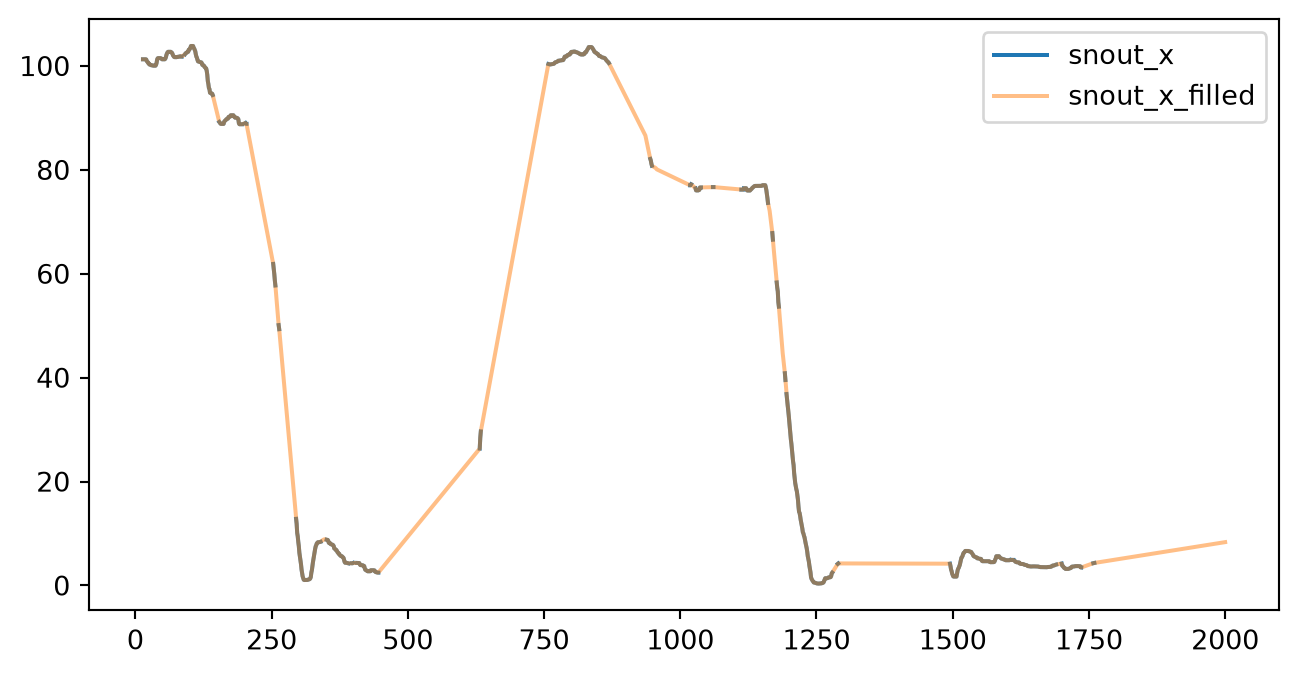

In [17]:
table["snout_x_filled"] = table["snout_x"].interpolate()
ax = table.loc[0:2000, ["snout_x"]].plot()
ax = table.loc[0:2000, ["snout_x_filled"]].plot(alpha=0.5, ax=ax)
plt.show()

## Build a table from arrays

In [18]:
speed = np.hypot(np.diff(table["body_x"]), np.diff(table["body_y"])) * 50
summary = pd.DataFrame({"time_s": table["time_s"].to_numpy()[1:], "speed": speed})
summary.head()

,time_s,speed
0,0.02,17.187922
1,0.04,7.752103
2,0.06,16.914408
3,0.08,11.262624
4,0.10,9.466632


- A dict of arrays of the same length becomes a DataFrame.

## Save, and read back

In [19]:
summary.to_csv("data/speed.csv", index=False)

In [20]:
pd.read_csv("data/speed.csv").head(3)

,time_s,speed
0,0.02,17.187922
1,0.04,7.752103
2,0.06,16.914408


## Small tables are tables too {.scrollable}

In [21]:
pd.read_csv("data/participants.tsv", sep="\t")

,participant_id,species,strain,strain_rrid
0,sub-rat2306,rattus norvegicus,RjHan:SD,RRID:RGD_38676310
1,sub-rat75,rattus norvegicus,RjHan:SD,RRID:RGD_38676310
2,sub-rat84,rattus norvegicus,RjHan:SD,RRID:RGD_38676310
3,sub-rat83,rattus norvegicus,RjHan:SD,RRID:RGD_38676310
4,sub-rat2403,rattus norvegicus,RjHan:SD,RRID:RGD_38676310
5,sub-rat1703,rattus norvegicus,RjHan:SD,RRID:RGD_38676310
6,sub-rat73,rattus norvegicus,RjHan:SD,RRID:RGD_38676310


## What the stats course will use

- `pd.read_csv`, `head`, `describe`, `[]`, `loc`, boolean filters, `dropna`, and `groupby` (new).
- The stats course uses the same objects and the same ideas.

# Part 2. scipy: functions you do not need to write yourself

## What is scipy?

- A collection of scientific functions built on NumPy: statistics, signals, images, interpolation, optimization.
- You import one submodule at a time: `from scipy import stats`.

## Smooth a signal

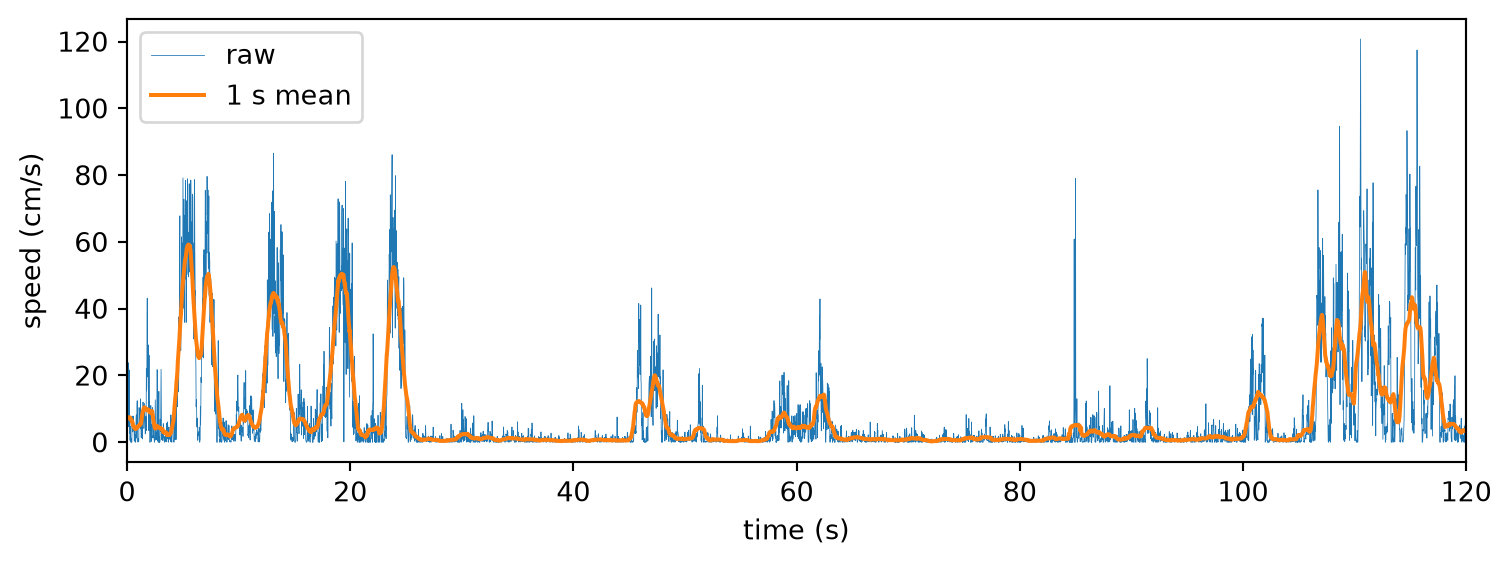

In [22]:
from scipy import ndimage

speed_smooth = ndimage.uniform_filter1d(speed, size=50)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(summary["time_s"], speed, linewidth=0.3, label="raw")
ax.plot(summary["time_s"], speed_smooth, label="1 s mean")
ax.set_xlim(0, 120)
ax.set_xlabel("time (s)")
ax.set_ylabel("speed (cm/s)")
ax.legend()
plt.show()

- In practical 1 you did this with `np.convolve`. The result is the same, and the name is clearer.

## Resample: behavior at 50 Hz, brain at 2 Hz

In [23]:
t_brain = np.arange(0.5, 720, 0.5)          # one brain image every 0.5 s
speed_brain = np.interp(t_brain, summary["time_s"], speed_smooth)
speed_brain.shape

(1439,)

- `np.interp` is linear interpolation. `scipy.interpolate` has splines and more.
- Brain and behavior must share one clock before you compare them.

## Statistics

In [24]:
from scipy import stats

summary_stats = stats.describe(speed)
summary_stats.mean, summary_stats.variance, summary_stats.minmax

(np.float64(5.428617566815626),
 np.float64(107.88890939273686),
 (np.float64(0.0), np.float64(120.75136636967443)))

- `describe` returns one object with named fields. You read each field by its name.

In [25]:
stats.pearsonr(table["body_x"], table["neck_x"])

PearsonRResult(statistic=np.float64(0.9816496909085876), pvalue=np.float64(0.0))

- `pearsonr` returns the correlation and a p-value. The stats course explains the p-value.

# Part 3. A line through a cloud

## The question

In [26]:
decoded = pd.read_csv("data/decode_regressor.tsv", sep="\t")
decoded.head()

,predicted,actual
0,28.061979,7.002245
1,27.068164,7.180451
2,25.917650,7.278370
3,24.610826,7.285528
4,23.158791,7.196360


- The paper decodes the rat's speed from brain images. How good is the decoding?
- Test set: 6417 time points. `actual` is the true speed. `predicted` is the decoded speed.

## Look at the data before you fit

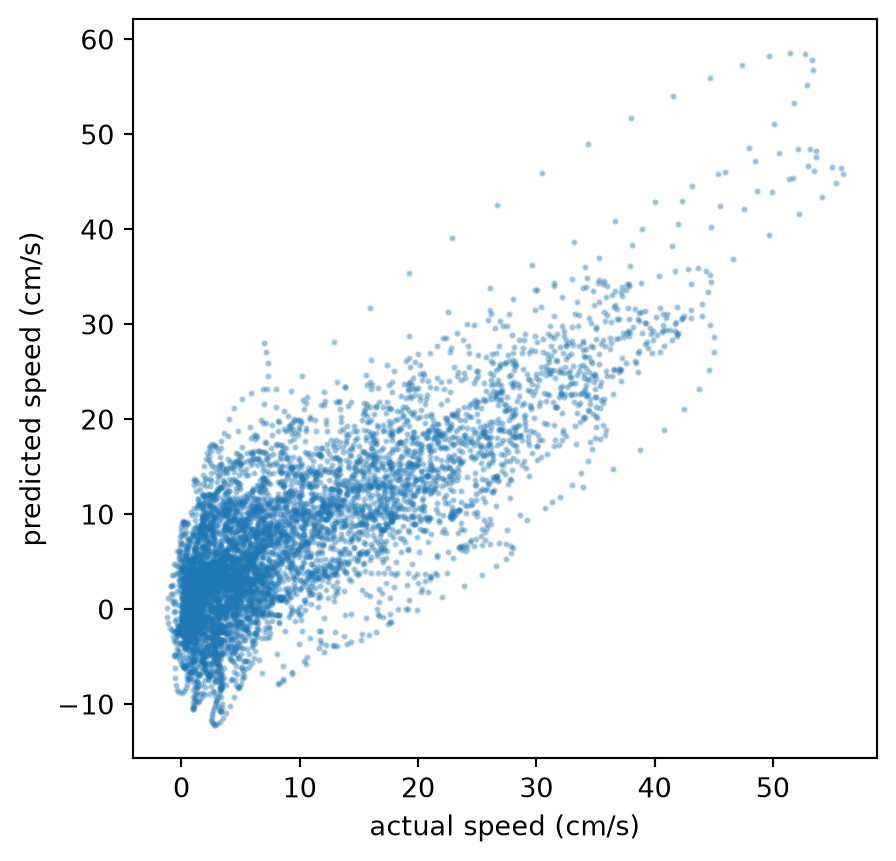

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(decoded["actual"], decoded["predicted"], s=2, alpha=0.3)
ax.set_xlabel("actual speed (cm/s)")
ax.set_ylabel("predicted speed (cm/s)")
plt.show()

## The line

In [28]:
result = stats.linregress(decoded["actual"], decoded["predicted"])
result.slope, result.intercept, result.rvalue

(np.float64(0.7473676841940903),
 np.float64(0.4415325565807455),
 np.float64(0.8097795971516388))

- `predicted ≈ intercept + slope × actual`. This line makes the sum of squared vertical errors smallest.

## Draw it {.smaller}

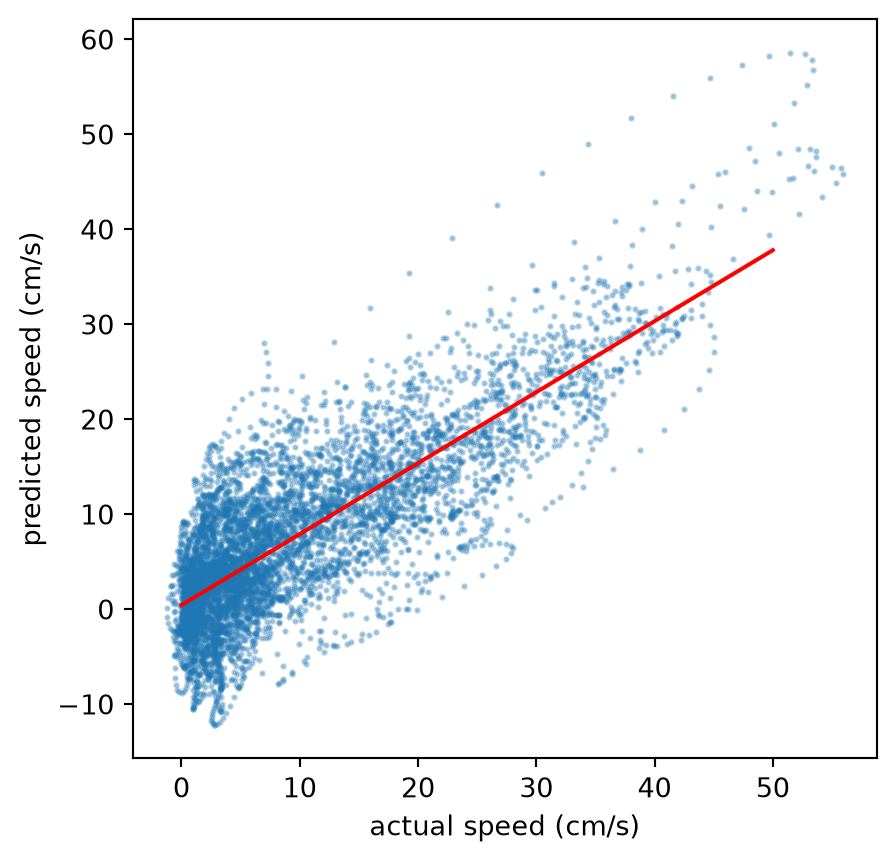

In [29]:
x_line = np.array([0, 50])
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(decoded["actual"], decoded["predicted"], s=2, alpha=0.3)
ax.plot(x_line, result.intercept + result.slope * x_line, color="red")
ax.set_xlabel("actual speed (cm/s)")
ax.set_ylabel("predicted speed (cm/s)")
plt.show()

## Residuals: what the line misses {.smaller}

In [30]:
residuals = decoded["predicted"] - (result.intercept + result.slope * decoded["actual"])
residuals.mean(), residuals.std()

(np.float64(6.377943210188837e-16), np.float64(5.464935912439161))

- The mean is about `6e-16`, which is zero up to rounding. A least-squares line always makes the mean of the residuals zero. The standard deviation, about 5.5 cm/s, is the typical size of one error.

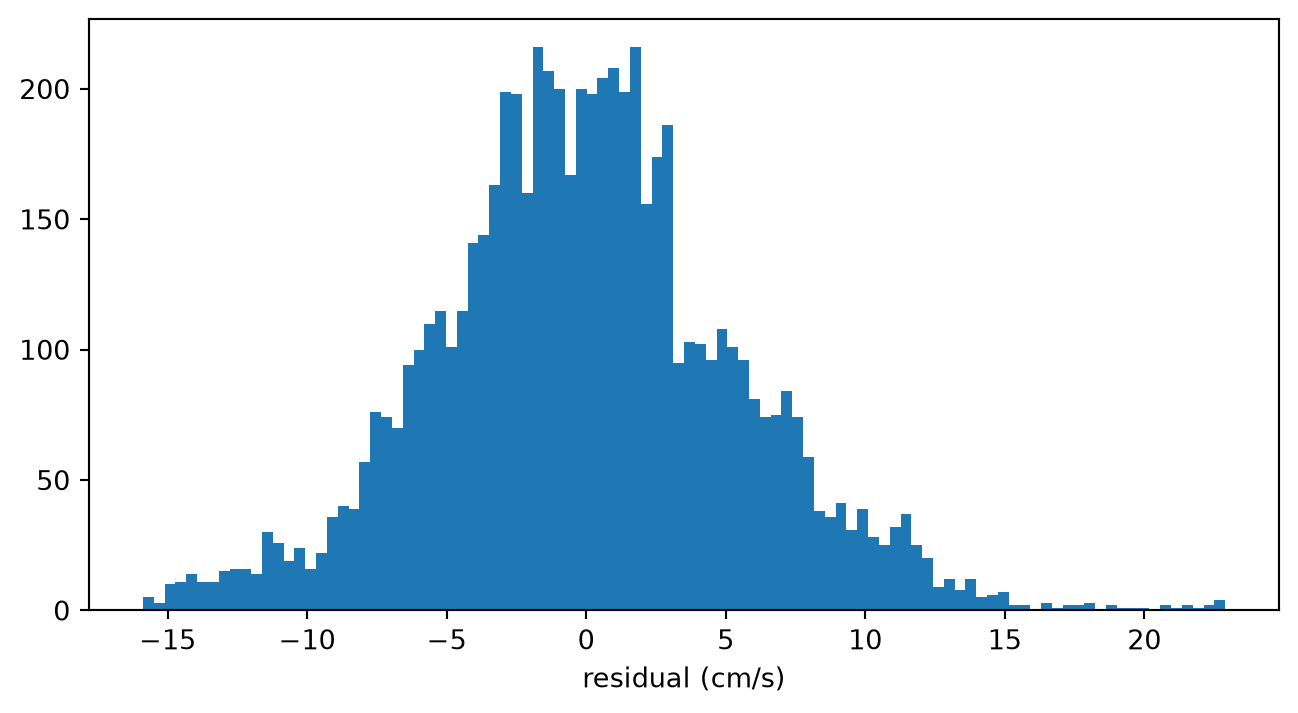

In [31]:
plt.hist(residuals, bins=100)
plt.xlabel("residual (cm/s)")
plt.show()

## r: how close are the points to the line?

In [32]:
result.rvalue, result.rvalue ** 2, np.corrcoef(decoded["actual"], decoded["predicted"])[0, 1]

(np.float64(0.8097795971516388),
 np.float64(0.6557429959630705),
 np.float64(0.8097795971516386))

- `r` is between −1 and 1. At 0 there is no linear relation. At 1 all points lie on one line that goes up.
- `r²` is the fraction of the variance of y that the line explains.

## Same line, other tools {.smaller}

In [33]:
np.polyfit(decoded["actual"], decoded["predicted"], 1)

array([0.74736768, 0.44153256])

In [34]:
import statsmodels.formula.api as smf

model = smf.ols("predicted ~ actual", data=decoded).fit()
model.params

Intercept    0.441533
actual       0.747368
dtype: float64

- `polyfit` returns `[slope, intercept]`. `statsmodels` fits the same line from a formula and returns the same numbers. The stats course uses `statsmodels`, because `model.summary()` gives many more statistics.

# Part 4. seaborn

## seaborn: plots that understand DataFrames

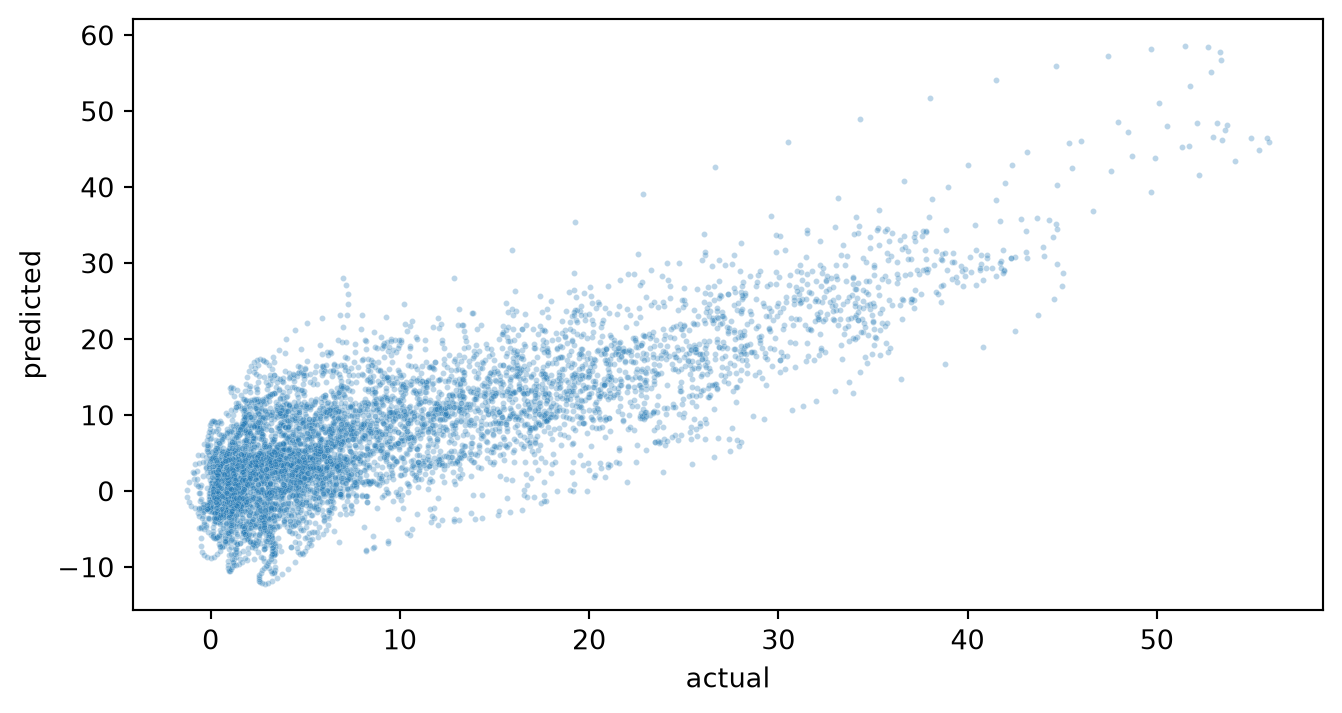

In [35]:
import seaborn as sns

sns.scatterplot(data=decoded, x="actual", y="predicted", s=5, alpha=0.3)
plt.show()

## Cloud and line in one call

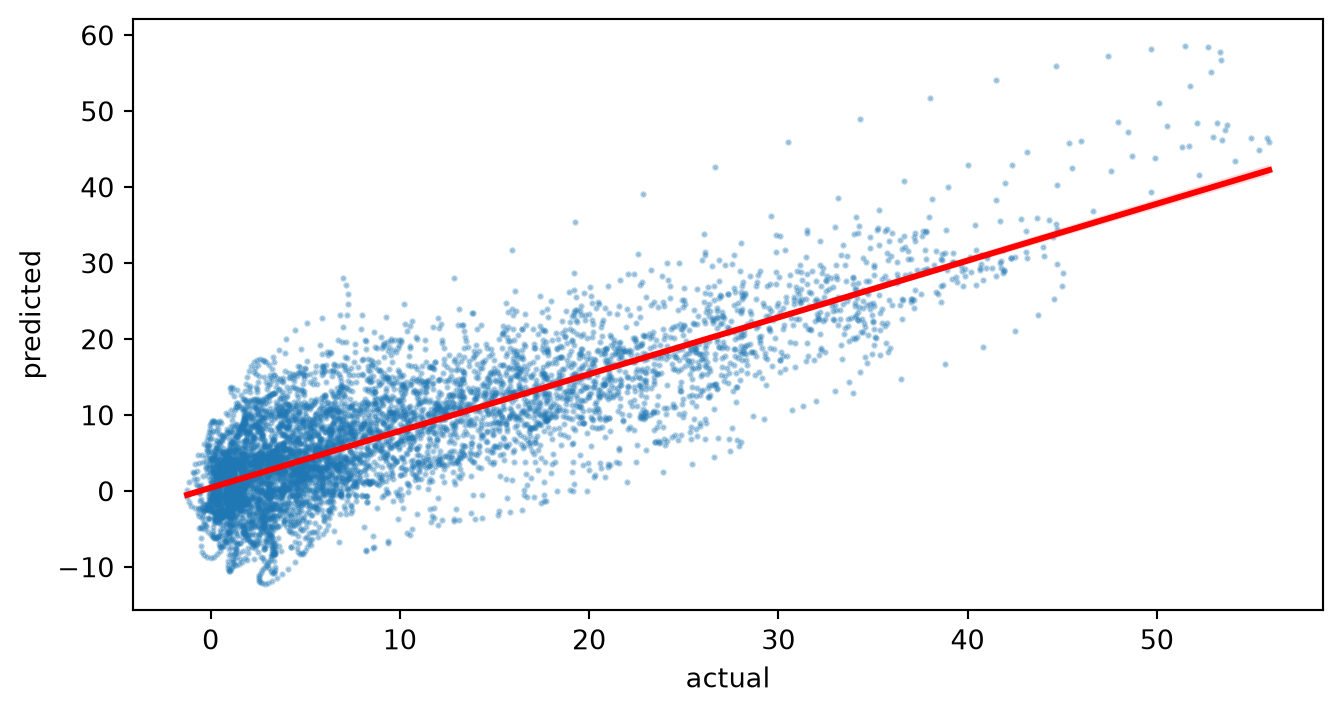

In [36]:
sns.regplot(data=decoded, x="actual", y="predicted",
            scatter_kws={"s": 2, "alpha": 0.3}, line_kws={"color": "red"})
plt.show()

## Distributions

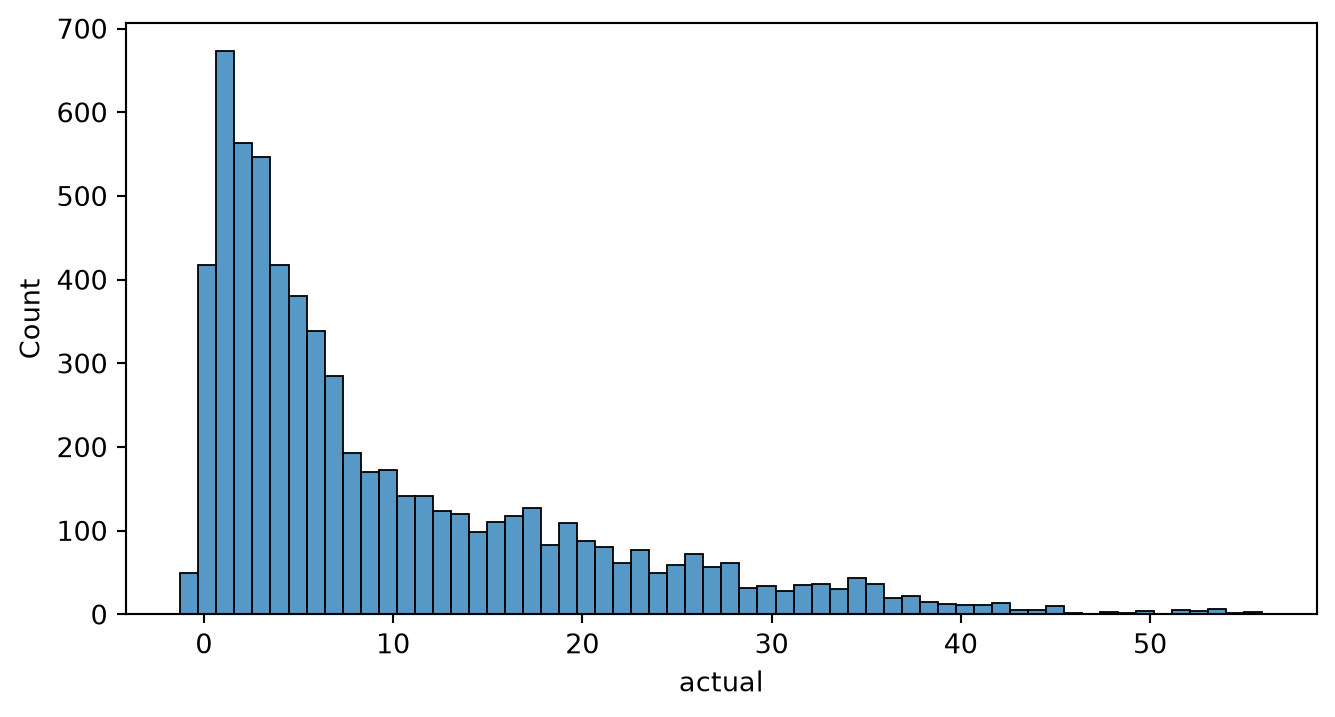

In [37]:
sns.histplot(decoded["actual"], bins=60)
plt.show()

- The stats course uses `sns.histplot`, `sns.boxplot`, `sns.regplot`, and `sns.load_dataset("penguins")`.

# Part 5. Practical 2

## Does the brain know the speed?

- Fit the line and compute r. Then center and scale both variables, fit again, and compare the new slope with r.
- Do the same with a control model and compare the two.
- Same rules: fill the blank, run the check.